# Practice 2 — Predictive Maintenance

**Dataset:** AI4I 2020 Predictive Maintenance  
**Objective:** Audit, analyze, and prepare industrial sensor data for machine learning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dat = pd.read_csv('../ai4i2020.csv')

-Checking the dataset

In [8]:
dat.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


UDI - number of row
<br>
Type - type of product quality
<br>
Rotational speed - how many rotation product makes
<br>
Torque - механическая нагрузка
<br>
Tool wear - износ оборудования
<br>
Machin Failure - был ли отказ?
<br>
TWF	Tool Wear Failure	Отказ, связанный с износом инструмента
<br>
HDF	Heat Dissipation Failure	Отказ, связанный с теплоотводом
<br>
PWF	Power Failure	Отказ, связанный с мощностью/рабочим режимом
<br>
OSF	Overstrain Failure	Отказ из-за чрезмерной нагрузки
<br>
RNF	Random Failure	Случайный отказ

In [9]:
dat.shape

(10000, 14)

In [10]:
dat.describe()


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

1.Check missing values

In [5]:
dat.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

2. Detect impossible values (domain reasoning):
<ul>
<li>Negative torque?</li>
<li>Temperature outside physical range?</li>
</ul>

In [ ]:
(dat['Torque [Nm]'] < 0).sum()

np.int64(0)

In [30]:
air_temp_max = (dat['Air temperature [K]']).max()
air_temp_min = (dat['Air temperature [K]']).min()
procc_temp_max = (dat['Process temperature [K]']).max()
procc_temp_min = (dat['Process temperature [K]']).min()

print(f'Air temp diapazone from {air_temp_min} to {air_temp_max}')
print(f'Process temp diapazone from {procc_temp_min} to {procc_temp_max}')

print((dat['Air temperature [K]'] < 0).sum()
,(dat['Process temperature [K]'] < 0).sum())

Air temp diapazone from 295.3 to 304.5
Process temp diapazone from 305.7 to 313.8
0 0


So there is no negative torque and temperature outside the physical range, also you can check this info by dat.describe()

3. Check duplicated records.

In [33]:
dat.duplicated().sum()

np.int64(0)

4. Check inconsistent failure flags.

In [40]:
print(((dat['Machine failure'] == 0) & ((dat['HDF'] == 1) | (dat['TWF'] == 1) | (dat['PWF'] == 1) | (dat['OSF'] == 1) | (dat['RNF'] == 1))).sum())
print(((dat['Machine failure'] == 1) & ((dat['HDF'] == 0) & (dat['TWF'] == 0) & (dat['PWF'] == 0) & (dat['OSF'] == 0) & (dat['RNF'] == 0))).sum())

18
9


Question:
If this data feeds a real-time control system, what risks exist?

If the wrong data feeds real-time control system, algorithm/model can make wrong decision in predicting which device is going to be broken soon, so the right data leads our future model to right prediciton or near right, 'cause prediciton can't be 100% right

### Short industrial audit summary (5–7 bullet points).


- The dataset contains 10,000 records and 14 features, in other words, 10,000 rows and 14 columns.
- There are no missing values in the dataset.
- No negative torque values were found.
- Air temperature ranges from 295.3 K to 304.5 K, while process temperature ranges from 305.7 K to 313.8 K. No physically impossible temperatures below 0 K were found.
- There are no duplicated records.
- 27 potentially inconsistent failure records were found: 18 records have Machine failure = 0 with at least one failure flag = 1, and 9 records have Machine failure = 1 while all failure flags = 0.

## PHASE 2 — Sensor Behavior Analysis

1. Analyze distribution.

In [ ]:
real_industrial_sensor = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

dat[real_industrial_sensor].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


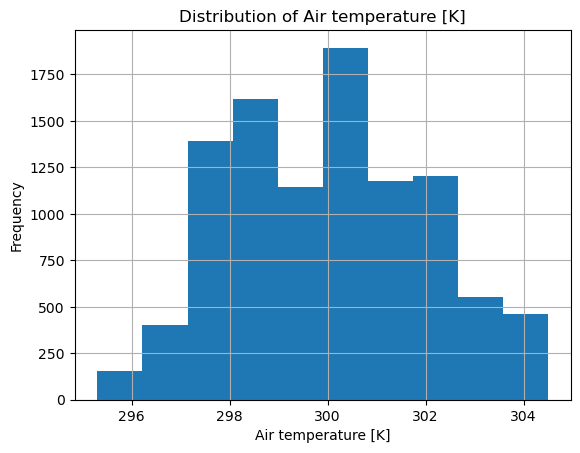

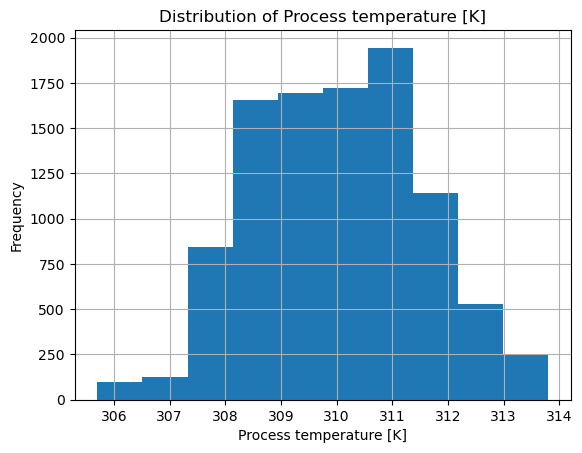

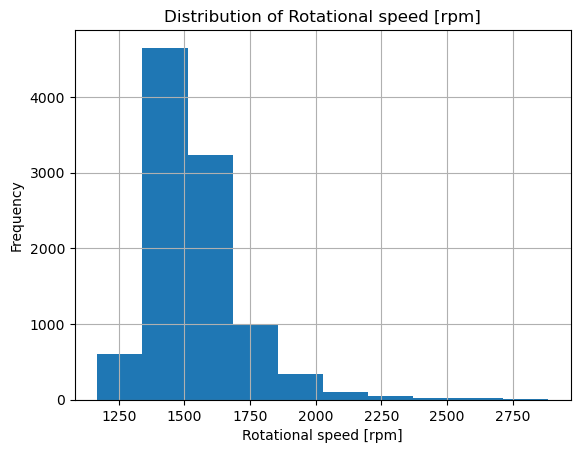

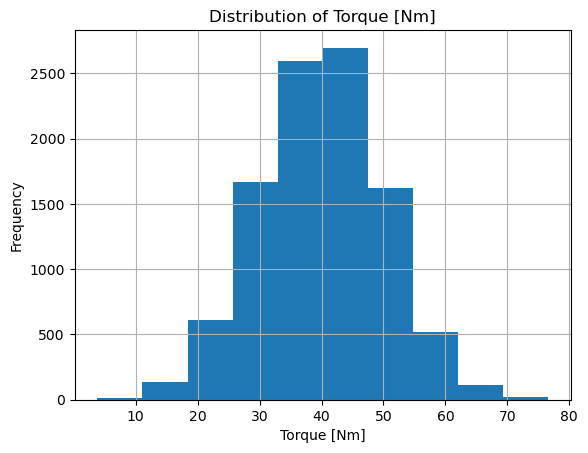

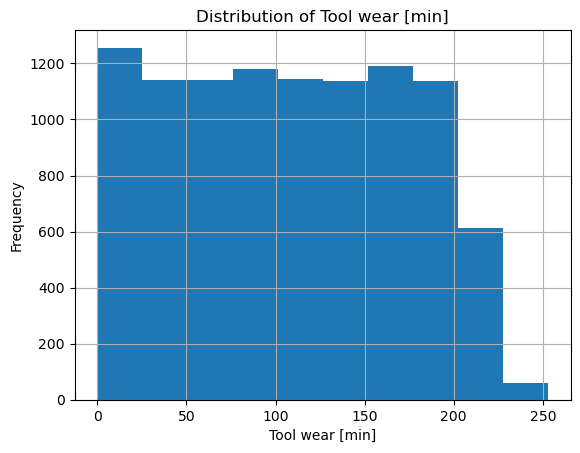

In [45]:
for item in real_industrial_sensor:
    plt.figure()
    dat[item].hist()
    plt.xlabel(item)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {item}')
    plt.show()

### Distribution Analysis

- Air temperature: Most values are concentrated around 297–302 K. The distribution is not perfectly normal.
- Process temperature: Most values are concentrated around 308–312 K. The distribution is also not perfectly normal.
- Rotational speed: Most values are around 1300–1700 rpm, but some values reach almost 2900 rpm. The distribution is right-skewed.
- Torque: The distribution is approximately normal and bell-shaped, centered around 40 Nm.
- Tool wear: Tool wear is distributed relatively evenly from 0 to around 200 minutes.

2. Compute dispersion (std, IQR).

In [62]:
for item in real_industrial_sensor:
    print(f'Name - {item}, Std - {dat[item].std():.2f}')
    print(f'Name - {item}, IQR - {dat[item].quantile(0.75) - dat[item].quantile(0.25)}')
    print()
    

Name - Air temperature [K], Std - 2.00
Name - Air temperature [K], IQR - 3.1999999999999886

Name - Process temperature [K], Std - 1.48
Name - Process temperature [K], IQR - 2.3000000000000114

Name - Rotational speed [rpm], Std - 179.28
Name - Rotational speed [rpm], IQR - 189.0

Name - Torque [Nm], Std - 9.97
Name - Torque [Nm], IQR - 13.599999999999994

Name - Tool wear [min], Std - 63.65
Name - Tool wear [min], IQR - 109.0



3. Identify extreme operating zones.

In [64]:
for item in real_industrial_sensor:
    print(f'Sensor - {item}, 1st {dat[item].quantile(0.01)} percentile, 99th {dat[item].quantile(0.99)} percentile')

Sensor - Air temperature [K], 1st 295.9 percentile, 99th 304.1 percentile
Sensor - Process temperature [K], 1st 306.6 percentile, 99th 313.2 percentile
Sensor - Rotational speed [rpm], 1st 1275.0 percentile, 99th 2188.01 percentile
Sensor - Torque [Nm], 1st 16.7 percentile, 99th 62.8 percentile
Sensor - Tool wear [min], 1st 0.0 percentile, 99th 222.0 percentile


Extreme Operating Zones

I used the 1st and 99th percentiles to identify statistical extreme operating zones.
Values below the 1st percentile or above the 99th percentile are considered extreme.
These values are not necessarily errors or failures, but they represent rare operating conditions.

In [65]:
dat[real_industrial_sensor].head()
    

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


In [80]:
condtion_true = (dat['Machine failure'] == 1)
condtion_false = (dat['Machine failure'] == 0)


for item in real_industrial_sensor:
    print(f'Item - {item}, mean - {dat[condtion_true][item].mean():.2f} Failed')
    print(f'Item - {item}, mean - {dat[condtion_false][item].mean():.2f} Normal')
    print()

Item - Air temperature [K], mean - 300.89 Failed
Item - Air temperature [K], mean - 299.97 Normal

Item - Process temperature [K], mean - 310.29 Failed
Item - Process temperature [K], mean - 310.00 Normal

Item - Rotational speed [rpm], mean - 1496.49 Failed
Item - Rotational speed [rpm], mean - 1540.26 Normal

Item - Torque [Nm], mean - 50.17 Failed
Item - Torque [Nm], mean - 39.63 Normal

Item - Tool wear [min], mean - 143.78 Failed
Item - Tool wear [min], mean - 106.69 Normal



Which sensors behave differently before failure? - Torque and Tool wear and Rotational speed

Which variables may be early warning signals? - Torque and Tool wear and Rotational speed


In [83]:
normal_means = []
fail_means = []
std_val = []
iqr_val = []
for item in real_industrial_sensor:
    std = dat[item].std()
    iqr = dat[item].quantile(0.75) - dat[item].quantile(0.25)
    mean_norm = dat[condtion_false][item].mean()
    mean_fail = dat[condtion_true][item].mean()
    normal_means.append(mean_norm)
    fail_means.append(mean_fail)
    std_val.append(std)
    iqr_val.append(iqr)

result_table = pd.DataFrame({
    'Sensor' : real_industrial_sensor,
    'Mean Normal' : normal_means,
    'Mean Failed': fail_means,
    'Std' : std_val,
    'IQR' : iqr_val
})

result_table.round(2)

,Sensor,Mean Normal,Mean Failed,Std,IQR
0,Air temperature [K],299.97,300.89,2.00,3.2
1,Process temperature [K],310.00,310.29,1.48,2.3
2,Rotational speed [rpm],1540.26,1496.49,179.28,189.0
3,Torque [Nm],39.63,50.17,9.97,13.6
4,Tool wear [min],106.69,143.78,63.65,109.0


Failed Machines has higher Torque and Tool wear

Failed Machines also have lower Rotational speed

Air and process temperatures show only small differences between normal and failed machines

As we can see Torque and Tool wear has a big difference between means comparing Failed and Normal machines, so they may be helpful for us

## PHASE 3 — Industrial Anomaly Detection

1. Detect anomalies using:

- Z-score

- IQR

In [124]:
z_score_anomalies = []
iqr_anomalies = []
z_failure_score = []
iqr_failure_score = [] 

for items in real_industrial_sensor:
    
    z_score = (dat[items] - dat[items].mean())/(dat[items].std())
    iqr = dat[items].quantile(0.75) - dat[items].quantile(0.25)
    lower_bound = dat[items].quantile(0.25) - 1.5*iqr
    upper_bound = dat[items].quantile(0.75) + 1.5*iqr
    iqr_anomaly = (dat[items] < lower_bound) | (dat[items] > upper_bound)

    print(f'Z-score anomalies for {items} = {(abs(z_score) > 3).sum()}')
    z_score_anomalies.append((abs(z_score) > 3).sum())
    print(f'IQR for item - {items} = {iqr}')
    print(f'Lower bound = {lower_bound}')
    print(f'Upper bound = {upper_bound}')
    print(f'IQR anomalies = {iqr_anomaly.sum()}')
    iqr_anomalies.append(iqr_anomaly.sum())

    print()


Z-score anomalies for Air temperature [K] = 0
IQR for item - Air temperature [K] = 3.1999999999999886
Lower bound = 293.5
Upper bound = 306.29999999999995
IQR anomalies = 0

Z-score anomalies for Process temperature [K] = 0
IQR for item - Process temperature [K] = 2.3000000000000114
Lower bound = 305.35
Upper bound = 314.55000000000007
IQR anomalies = 0

Z-score anomalies for Rotational speed [rpm] = 164
IQR for item - Rotational speed [rpm] = 189.0
Lower bound = 1139.5
Upper bound = 1895.5
IQR anomalies = 418

Z-score anomalies for Torque [Nm] = 25
IQR for item - Torque [Nm] = 13.599999999999994
Lower bound = 12.800000000000011
Upper bound = 67.19999999999999
IQR anomalies = 69

Z-score anomalies for Tool wear [min] = 0
IQR for item - Tool wear [min] = 109.0
Lower bound = -110.5
Upper bound = 325.5
IQR anomalies = 0



In [125]:
for items in real_industrial_sensor:

    iqr = dat[items].quantile(0.75) - dat[items].quantile(0.25)
    lower_bound = dat[items].quantile(0.25) - 1.5*iqr
    upper_bound = dat[items].quantile(0.75) + 1.5*iqr
    z_score = (dat[items] - dat[items].mean())/(dat[items].std())
    iqr_anomaly = (dat[items] < lower_bound) | (dat[items] > upper_bound)
    
    

    z_failure = ((abs(z_score) > 3) & (dat['Machine failure'] == 1)).sum()
    iqr_failure = ((iqr_anomaly) & (dat['Machine failure'] == 1)).sum()
        
    print(f'Z_failure - {z_failure} for {items}')
    print(f'IQR failure - {iqr_failure} for {items}')

    z_failure_score.append(((abs(z_score) > 3) & (dat['Machine failure'] == 1)).sum())
    iqr_failure_score.append(((iqr_anomaly) & (dat['Machine failure'] == 1)).sum())

Z_failure - 0 for Air temperature [K]
IQR failure - 0 for Air temperature [K]
Z_failure - 0 for Process temperature [K]
IQR failure - 0 for Process temperature [K]
Z_failure - 33 for Rotational speed [rpm]
IQR failure - 35 for Rotational speed [rpm]
Z_failure - 24 for Torque [Nm]
IQR failure - 62 for Torque [Nm]
Z_failure - 0 for Tool wear [min]
IQR failure - 0 for Tool wear [min]


In [126]:


result_table = pd.DataFrame({
    'Sensor' : real_industrial_sensor,
    'z_anomalies' : z_score_anomalies,
    'z_anomalies_falies': z_failure_score,
    'IQR_anomalies' : iqr_anomalies,
    'IQR_failure' : iqr_failure_score
})

result_table
    
   


,Sensor,z_anomalies,z_anomalies_falies,IQR_anomalies,IQR_failure
0,Air temperature [K],0,0,0,0
1,Process temperature [K],0,0,0,0
2,Rotational speed [rpm],164,33,418,35
3,Torque [Nm],25,24,69,62
4,Tool wear [min],0,0,0,0


Are anomalies noise or early breakdown signals?

Anomalies in Torque seems to be early breakdown signal 'cause z_falies is 24 out of 25 available. Also 62 out of 69 iqr_failure anomalies, so torque can be a good sign for preventioning break of machines. But if we take Rational speed, anomalies just a noise, and we can't take them seriously.

Should we remove them or mark them as risk indicators?

I would not remove these anomalies automatically because some of them are associated with machine failures. Torque anomalies should be marked as risk indicators. Rotational speed anomalies can also be kept and marked as unusual operating conditions because removing them may result in losing useful information.


## PHASE 4 — Risk Segmentation (Business-Oriented)

Create industrial risk zones.

Tool wear:

0–100 → Normal

100–200 → Maintenance soon

200+ → Critical

In [131]:
dat['Tool wear Risk'] = pd.cut(dat['Tool wear [min]'], bins = [0, 100, 200, np.inf], labels = ['Normal','Maintenance Soon','Critial'], right=False)
dat['Tool wear Risk'].value_counts()

Tool wear Risk
Normal              4620
Maintenance Soon    4579
Critial              801
Name: count, dtype: int64

In [136]:
failure_rate_risk_per_zone = dat.groupby('Tool wear Risk')['Machine failure'].mean() * 100
print(failure_rate_risk_per_zone)

Tool wear Risk
Normal               2.229437
Maintenance Soon     2.467788
Critial             15.355805
Name: Machine failure, dtype: float64


/var/folders/hs/hj4pbp390fl8bl6m_js8rq8c0000gn/T/ipykernel_68584/2928998711.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate_risk_per_zone = dat.groupby('Tool wear Risk')['Machine failure'].mean() * 100


In [138]:
table_failure_rate_risk = failure_rate_risk_per_zone.reset_index()
table_failure_rate_risk

,Tool wear Risk,Machine failure
0,Normal,2.229437
1,Maintenance Soon,2.467788
2,Critial,15.355805


In [139]:
table_failure_rate_risk.columns = ['Tool wear Risk', 'Failure Rate (%)']
table_failure_rate_risk

,Tool wear Risk,Failure Rate (%)
0,Normal,2.229437
1,Maintenance Soon,2.467788
2,Critial,15.355805


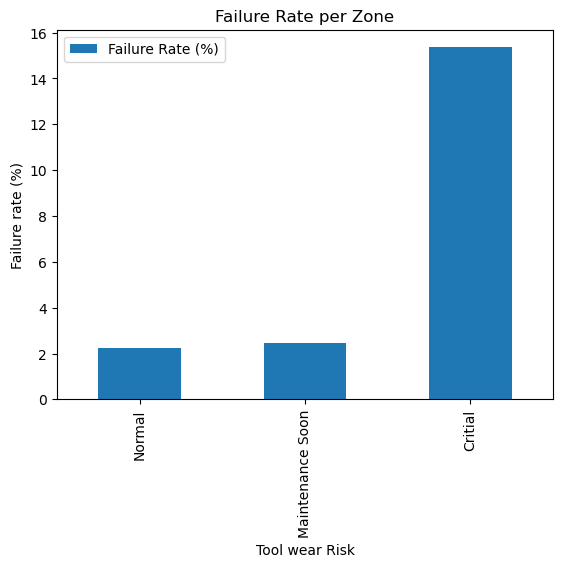

In [142]:
table_failure_rate_risk.plot.bar(x='Tool wear Risk', y='Failure Rate (%)')
plt.title('Failure Rate per Zone')
plt.xlabel('Tool wear Risk')
plt.ylabel('Failure rate (%)')
plt.show()

### Does Tool Wear Risk Segmentation Meaningfully Separate Failure Probability?

Yes. There is only a small difference between the Normal and Maintenance Soon zones, with failure rates of 2.23% and 2.47%.

However, the Critical zone has a much higher failure rate of 15.36%. Therefore, tool wear risk segmentation successfully identifies a high-risk group.

Temperature difference (Process – Air):

Small → Stable

Medium → Warning

Large → Overheating risk

In [143]:
dat['Temperature difference'] = dat['Process temperature [K]'] - dat['Air temperature [K]']
dat['Temperature difference'].describe()

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temperature difference, dtype: float64

In [144]:
dat['Temperature difference'] = pd.cut(dat['Temperature difference'], bins = [-np.inf, 9.3, 11.0, np.inf], labels=['Stable', 'Warning', 'Overheating risk'])
dat['Temperature difference'].value_counts()

Temperature difference
Warning             5299
Stable              2559
Overheating risk    2142
Name: count, dtype: int64

In [145]:
failure_risk_per_zone = dat.groupby('Temperature difference')['Machine failure'].mean() * 100
failure_risk_per_zone

/var/folders/hs/hj4pbp390fl8bl6m_js8rq8c0000gn/T/ipykernel_68584/2477698992.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_risk_per_zone = dat.groupby('Temperature difference')['Machine failure'].mean() * 100


Temperature difference
Stable              6.682298
Warning             2.302321
Overheating risk    2.147526
Name: Machine failure, dtype: float64

In [147]:
failure_rate_risk_per_zone = failure_risk_per_zone.reset_index()
failure_rate_risk_per_zone

,Temperature difference,Machine failure
0,Stable,6.682298
1,Warning,2.302321
2,Overheating risk,2.147526


In [148]:
failure_rate_risk_per_zone.columns = ['Temperature difference',  'Failure Rate (%)']
failure_rate_risk_per_zone

,Temperature difference,Failure Rate (%)
0,Stable,6.682298
1,Warning,2.302321
2,Overheating risk,2.147526


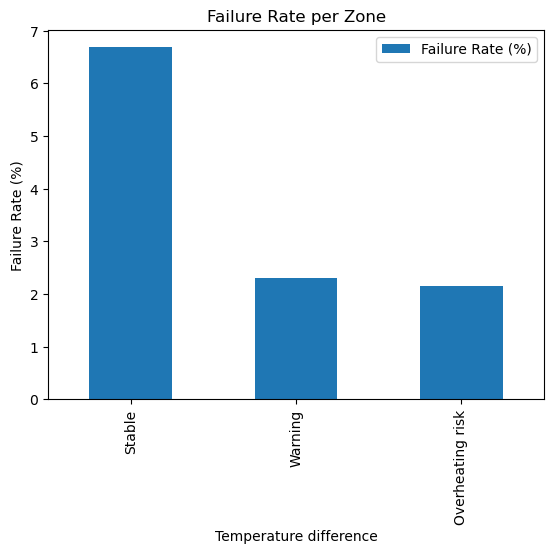

In [149]:
failure_rate_risk_per_zone.plot.bar(x = 'Temperature difference', y = 'Failure Rate (%)')
plt.title('Failure Rate per Zone')
plt.xlabel('Temperature difference')
plt.ylabel('Failure Rate (%)')
plt.show()

### Does Temperature Difference Risk Segmentation Meaningfully Separate Failure Probability?

No, the temperature difference segmentation does not clearly separate machine failure probability in the expected direction.

The Stable zone has the highest failure rate at 6.68%, while the Warning zone has 2.30% and the Overheating Risk zone has 2.15%.

Therefore, a larger Process-Air temperature difference does not appear to indicate a higher machine failure risk in this dataset. Temperature difference alone may not be a strong risk indicator.